In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import rdkit 
from rdkit import Chem ,DataStructs
from rdkit.Chem import AllChem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem.EState import Fingerprinter
import sklearn
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import joblib
from sklearn import gaussian_process
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, RBF

# DATA LOADING

In [163]:
names = ['Chemical Structure','Log P']
lp = pd.read_csv('logP_dataset.csv', names=names)
lp

,Chemical Structure,Log P
0,C[C@H]([C@@H](C)Cl)Cl,2.3
1,C(C=CBr)N,0.3
2,CCC(CO)Br,1.3
3,[13CH3][13CH2][13CH2][13CH2][13CH2][13CH2]O,2.0
4,CCCOCCP,0.6
...,...,...
14605,CCC(SC)Br,2.7
14606,[2H]C([2H])([C@@H](CO)O)O,-1.8
14607,CC(C)NNC,0.4
14608,C[C@H]1CCC[CH]1,3.4


In [164]:
lp.info()

<class 'pandas.DataFrame'>
RangeIndex: 14610 entries, 0 to 14609
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Chemical Structure  14610 non-null  str    
 1   Log P               14610 non-null  float64
dtypes: float64(1), str(1)
memory usage: 228.4 KB


In [165]:
lp.describe()

,Log P
count,14610.000000
mean,0.998665
std,1.300486
min,-3.600000
25%,0.100000
50%,1.000000
75%,1.800000
max,6.200000


# DATA PRE PROCESSING & VISUALISATION 

In [166]:
#a function to calculate molecular descriptors for an input mol
def get_fps(mol):
    calc=MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    ds = np.asarray(calc.CalcDescriptors(mol))
    
#     arr=Fingerprinter.FingerprintMol(mol)[0]
    
    return ds

In [167]:
# Call RDKit functions to generate molecule descriptors for the data set.
lp['molecule'] = lp['Chemical Structure'].apply(Chem.MolFromSmiles)
lp['Descriptors'] = lp['molecule'].apply(get_fps)

lp.head()

,Chemical Structure,Log P,molecule,Descriptors
0,C[C@H]([C@@H](C)Cl)Cl,2.3,<rdkit.Chem.rdchem.Mol object at 0x127fec2e0>,"[5.48070987654321, 5.48070987654321, 0.0895061..."
1,C(C=CBr)N,0.3,<rdkit.Chem.rdchem.Mol object at 0x127fec3c0>,"[5.022222222222222, 5.022222222222222, 0.61631..."
2,CCC(CO)Br,1.3,<rdkit.Chem.rdchem.Mol object at 0x127fec430>,"[8.28789351851852, 8.28789351851852, 0.2465277..."
3,[13CH3][13CH2][13CH2][13CH2][13CH2][13CH2]O,2.0,<rdkit.Chem.rdchem.Mol object at 0x127fec890>,"[8.292882653061223, 8.292882653061223, 0.36111..."
4,CCCOCCP,0.6,<rdkit.Chem.rdchem.Mol object at 0x127fec900>,"[5.111111111111112, 5.111111111111112, 0.88740..."


In [168]:
descriptors = [x[0] for x in Descriptors._descList]
descriptors

['MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'SMR_VSA6',


In [169]:
desc_data = np.array(list(lp['Descriptors']))
logP = lp['Log P']

In [170]:
desc_data.shape

(14610, 217)

In [171]:
#Adding Log P to dataframe
df = pd.DataFrame(desc_data, columns=descriptors)
full_df = pd.concat([df, logP], axis=1)
full_df

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,Log P
0,5.480710,5.480710,0.089506,0.089506,0.473544,20.000000,127.014000,118.950000,126.000306,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.3
1,5.022222,5.022222,0.616319,0.616319,0.567701,10.000000,135.992000,129.944000,134.968361,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3
2,8.287894,8.287894,0.246528,0.246528,0.589679,14.500000,153.019000,143.947000,151.983677,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3
3,8.292883,8.292883,0.361111,0.361111,0.427695,9.428571,108.131129,94.019129,108.124594,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0
4,5.111111,5.111111,0.887407,0.887407,0.400945,9.428571,120.132000,107.028000,120.070402,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14605,3.438657,3.438657,0.664352,0.664352,0.571946,14.500000,169.087000,160.015000,167.960833,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.7
14606,8.319444,8.319444,0.774306,-2.685764,0.383258,21.833333,94.106204,84.030000,94.059898,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.8
14607,2.958333,2.958333,0.537037,0.537037,0.468365,10.000000,88.154000,76.058000,88.100048,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4
14608,2.402778,2.402778,0.921296,0.921296,0.419974,25.500000,83.154000,72.066000,83.086075,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.4


In [172]:
#Drop null values
df_drop_na = full_df.dropna(axis=0)
df_drop_na

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,Log P
0,5.480710,5.480710,0.089506,0.089506,0.473544,20.000000,127.014000,118.950000,126.000306,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.3
1,5.022222,5.022222,0.616319,0.616319,0.567701,10.000000,135.992000,129.944000,134.968361,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3
2,8.287894,8.287894,0.246528,0.246528,0.589679,14.500000,153.019000,143.947000,151.983677,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3
3,8.292883,8.292883,0.361111,0.361111,0.427695,9.428571,108.131129,94.019129,108.124594,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0
4,5.111111,5.111111,0.887407,0.887407,0.400945,9.428571,120.132000,107.028000,120.070402,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14605,3.438657,3.438657,0.664352,0.664352,0.571946,14.500000,169.087000,160.015000,167.960833,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.7
14606,8.319444,8.319444,0.774306,-2.685764,0.383258,21.833333,94.106204,84.030000,94.059898,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.8
14607,2.958333,2.958333,0.537037,0.537037,0.468365,10.000000,88.154000,76.058000,88.100048,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4
14608,2.402778,2.402778,0.921296,0.921296,0.419974,25.500000,83.154000,72.066000,83.086075,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.4


In [173]:
df_drop_na.isna().sum()

MaxAbsEStateIndex    0
MaxEStateIndex       0
MinAbsEStateIndex    0
MinEStateIndex       0
qed                  0
                    ..
fr_thiocyan          0
fr_thiophene         0
fr_unbrch_alkane     0
fr_urea              0
Log P                0
Length: 218, dtype: int64

In [174]:
#Renaming dataframe
coeff = df_drop_na.corr()
coeff

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,Log P
MaxAbsEStateIndex,1.000000,1.000000,-0.265225,-0.648151,0.036078,0.055770,-0.138934,-0.121660,-0.139165,0.012345,...,NaN,NaN,-0.009966,-0.008615,-0.014757,NaN,-0.011072,-0.066798,NaN,-0.184726
MaxEStateIndex,1.000000,1.000000,-0.265225,-0.648151,0.036078,0.055770,-0.138934,-0.121660,-0.139165,0.012345,...,NaN,NaN,-0.009966,-0.008615,-0.014757,NaN,-0.011072,-0.066798,NaN,-0.184726
MinAbsEStateIndex,-0.265225,-0.265225,1.000000,-0.046015,-0.051476,0.165613,0.009788,0.010228,0.010039,-0.158903,...,NaN,NaN,0.042034,-0.006611,0.022575,NaN,0.011482,0.065543,NaN,0.142711
MinEStateIndex,-0.648151,-0.648151,-0.046015,1.000000,-0.066723,-0.399605,0.089724,0.088666,0.090589,0.018033,...,NaN,NaN,0.026843,0.002949,0.025131,NaN,0.020165,0.139189,NaN,0.107322
qed,0.036078,0.036078,-0.051476,-0.066723,1.000000,0.124756,0.191335,0.162781,0.189165,0.199980,...,NaN,NaN,-0.037082,-0.003551,0.005838,NaN,0.004102,0.009263,NaN,0.342066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fr_thiocyan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fr_thiophene,-0.011072,-0.011072,0.011482,0.020165,0.004102,-0.007161,-0.025634,-0.022401,-0.025640,-0.046053,...,NaN,NaN,-0.001027,-0.000342,-0.000802,NaN,1.000000,-0.007834,NaN,0.018235
fr_unbrch_alkane,-0.066798,-0.066798,0.065543,0.139189,0.009263,-0.105461,0.000353,-0.030111,0.001041,0.325893,...,NaN,NaN,-0.009597,-0.003197,-0.007500,NaN,-0.007834,1.000000,NaN,0.321662
fr_urea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
#List of features more than threshold
thres = 0.25
greater_than_thres =  coeff.loc[(coeff['Log P'] >= thres)]
greater_than_thres_list = [row for row in greater_than_thres['Log P'].index]
greater_than_thres_list

['qed',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'MinPartialCharge',
 'BCUT2D_MWHI',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'Chi0v',
 'Chi1v',
 'HallKierAlpha',
 'LabuteASA',
 'PEOE_VSA6',
 'SMR_VSA10',
 'SMR_VSA5',
 'SlogP_VSA12',
 'SlogP_VSA4',
 'SlogP_VSA5',
 'EState_VSA5',
 'EState_VSA8',
 'VSA_EState10',
 'VSA_EState7',
 'VSA_EState8',
 'MolLogP',
 'MolMR',
 'fr_alkyl_halide',
 'fr_halogen',
 'fr_unbrch_alkane',
 'Log P']

In [176]:
#List of features less than threshold
smaller_than_neg_thres =  coeff.loc[(coeff['Log P'] <= -thres)]
smaller_than_neg_thres_list = [row for row in smaller_than_neg_thres['Log P'].index]
smaller_than_neg_thres_list

['MaxAbsPartialCharge',
 'PEOE_VSA1',
 'SMR_VSA1',
 'SMR_VSA3',
 'SMR_VSA6',
 'SlogP_VSA1',
 'SlogP_VSA2',
 'TPSA',
 'VSA_EState3',
 'VSA_EState4',
 'NHOHCount',
 'NOCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'fr_Al_OH',
 'fr_Al_OH_noTert',
 'fr_NH1',
 'fr_NH2']

In [177]:
#Combining the list
high_corr_features = greater_than_thres_list + smaller_than_neg_thres_list
high_corr_features.remove('Log P')
high_corr_features.remove('MolLogP')
high_corr_features


['qed',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'MinPartialCharge',
 'BCUT2D_MWHI',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'Chi0v',
 'Chi1v',
 'HallKierAlpha',
 'LabuteASA',
 'PEOE_VSA6',
 'SMR_VSA10',
 'SMR_VSA5',
 'SlogP_VSA12',
 'SlogP_VSA4',
 'SlogP_VSA5',
 'EState_VSA5',
 'EState_VSA8',
 'VSA_EState10',
 'VSA_EState7',
 'VSA_EState8',
 'MolMR',
 'fr_alkyl_halide',
 'fr_halogen',
 'fr_unbrch_alkane',
 'MaxAbsPartialCharge',
 'PEOE_VSA1',
 'SMR_VSA1',
 'SMR_VSA3',
 'SMR_VSA6',
 'SlogP_VSA1',
 'SlogP_VSA2',
 'TPSA',
 'VSA_EState3',
 'VSA_EState4',
 'NHOHCount',
 'NOCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'fr_Al_OH',
 'fr_Al_OH_noTert',
 'fr_NH1',
 'fr_NH2']

In [178]:
#dataframe for training model
df_cleaned = pd.concat([df_drop_na[high_corr_features], df_drop_na['Log P']], axis=1)

                          qed     MolWt  HeavyAtomMolWt  ExactMolWt  \
qed                  1.000000  0.191335        0.162781    0.189165   
MolWt                0.191335  1.000000        0.995629    0.999952   
HeavyAtomMolWt       0.162781  0.995629        1.000000    0.995355   
ExactMolWt           0.189165  0.999952        0.995355    1.000000   
MinPartialCharge     0.067887  0.233654        0.233825    0.232194   
BCUT2D_MWHI          0.051039  0.834979        0.849950    0.835515   
BCUT2D_LOGPHI        0.303552  0.274584        0.272677    0.273809   
BCUT2D_LOGPLOW       0.044774  0.137234        0.170582    0.136138   
Chi0v                0.322558  0.707511        0.667933    0.707938   
Chi1v                0.238582  0.515905        0.493027    0.516910   
HallKierAlpha        0.146792  0.747700        0.757565    0.746435   
LabuteASA            0.316207  0.675561        0.618647    0.675729   
PEOE_VSA6            0.271749  0.487445        0.459215    0.486565   
SMR_VS

<Axes: >

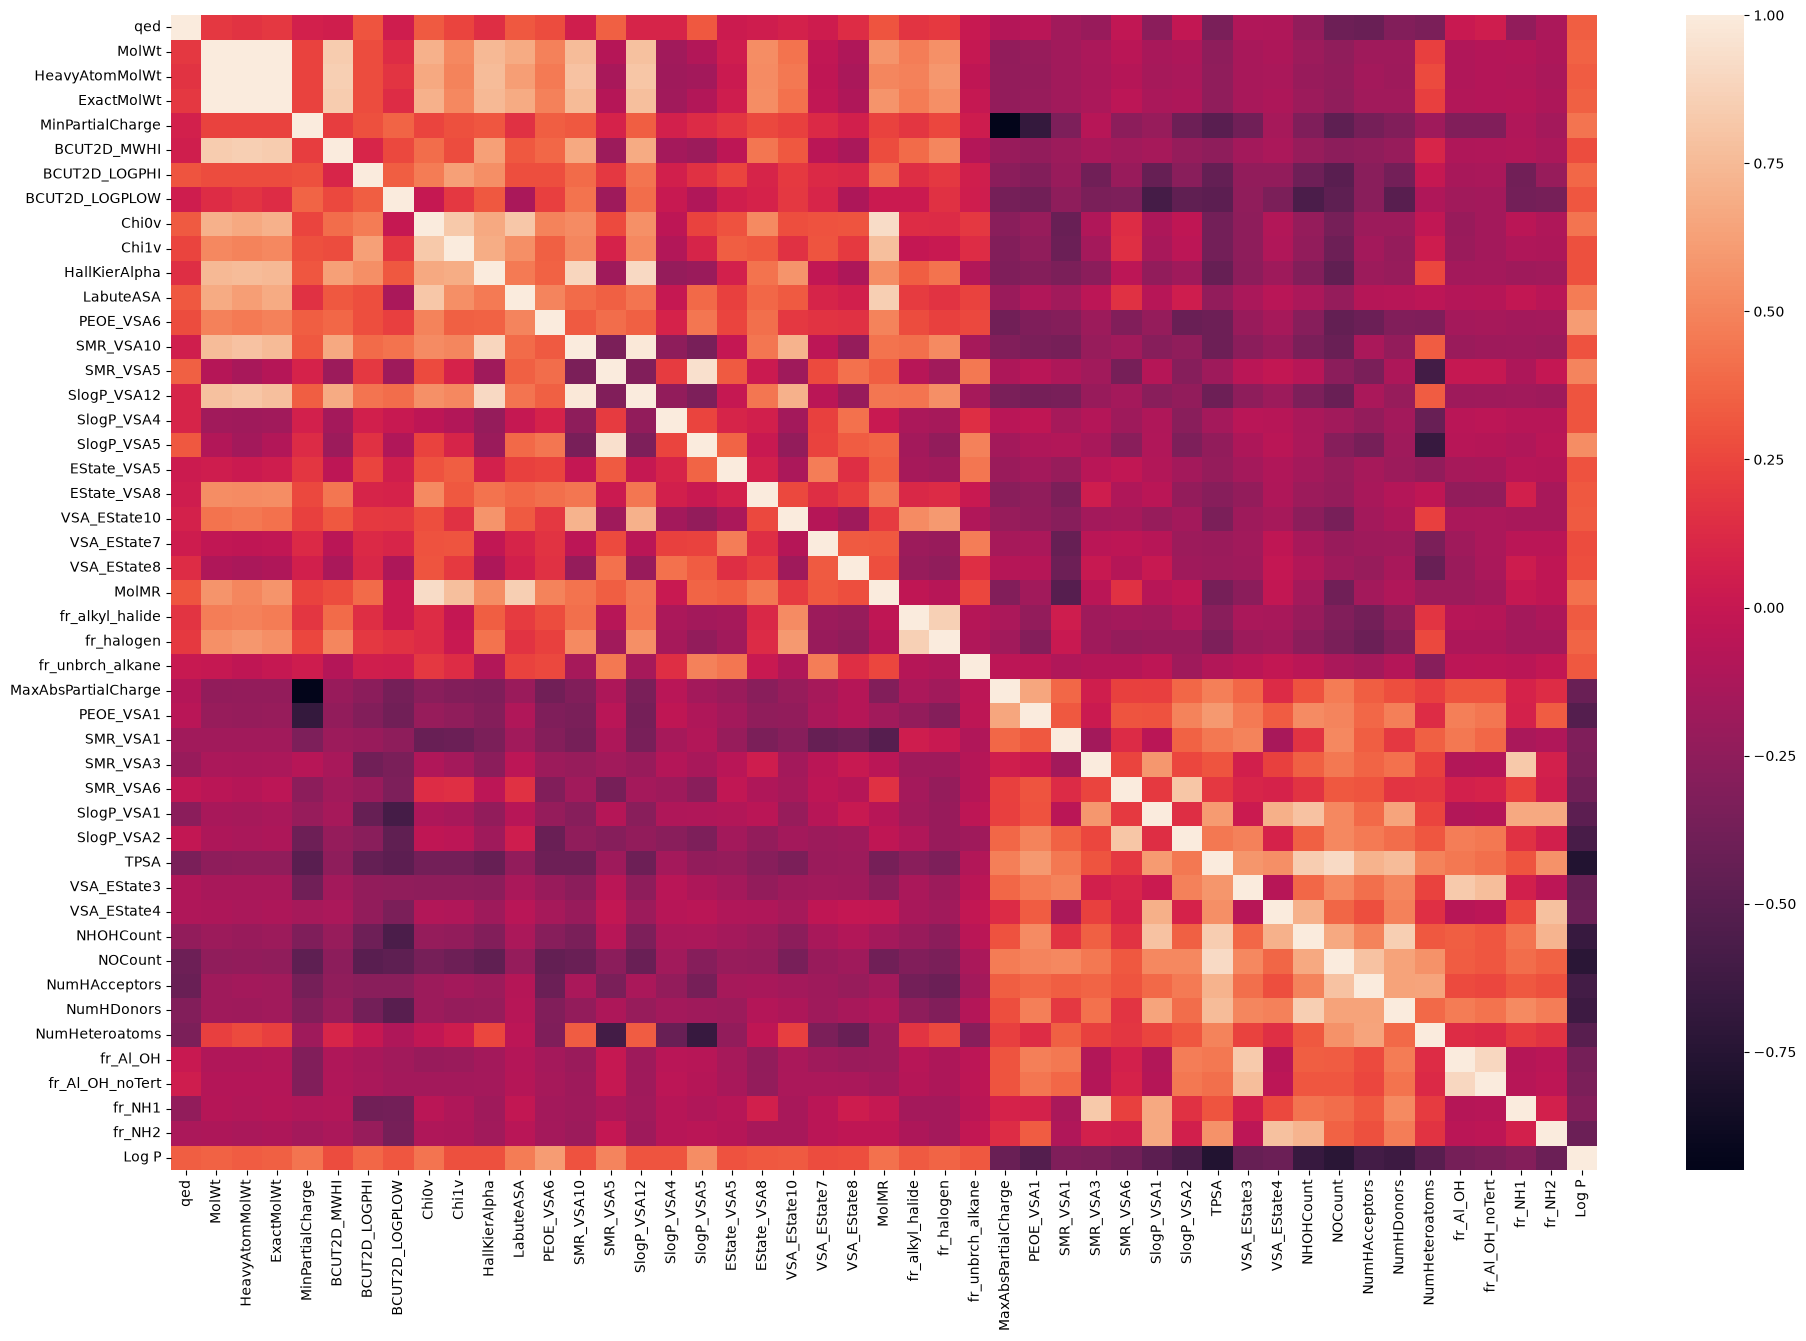

In [179]:
#Plotting heatmap
coeff = df_cleaned.corr()
print(coeff)
plt.figure(figsize=(23,15))
sns.heatmap(coeff)

In [180]:
X = df_drop_na[high_corr_features].to_numpy()
X.shape

(14329, 46)

In [181]:
y = df_drop_na['Log P'].to_numpy()
y.shape

(14329,)

/var/folders/jk/t956fdg96pz9k5f4xjjx4frh0000gn/T/ipykernel_11775/2715483860.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(y, bins = 40, color = 'blue')


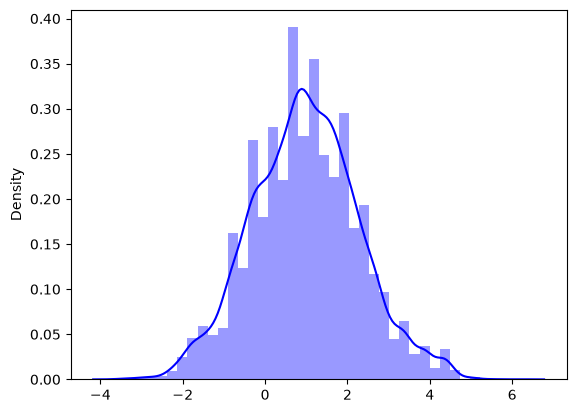

In [182]:
#distrubution for log p
ax = sns.distplot(y, bins = 40, color = 'blue')

# DATA SPLITTING 

In [183]:
st = StandardScaler()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train = st.fit_transform(x_train)
X_test = st.transform(x_test)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10746, 46)
(3583, 46)
(10746,)
(3583,)


# LINEAR REGRESSION 

In [184]:
# Model initialization
regression_model = LinearRegression()
# Fit the data(train the model)
regression_model.fit(X_train, y_train)
# Predict
y_predicted = regression_model.predict(X_test)

# model evaluation
mse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

/var/folders/jk/t956fdg96pz9k5f4xjjx4frh0000gn/T/ipykernel_11775/2402512841.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=4)


Slope: [-1.40059586e-02  6.54841702e-02 -5.61620590e+00  5.58700718e+00
 -2.11493560e-02 -1.97191112e-02 -2.14038615e-04 -3.58546287e-02
  1.68218989e-01  2.02149687e-01 -4.45492696e-01  3.47434865e-01
  9.48395212e-02  7.89230761e-01  1.33836413e-01 -3.22503583e-01
  1.21393775e-01  1.04568242e-01  1.82076448e-02  1.91774322e-02
  1.71120612e-02  9.88644089e-02  1.21468116e-01 -8.84147740e-01
  1.08533521e-02  4.93090978e-01  4.99798360e-02 -1.32513063e-02
 -6.57432679e-02 -2.35109605e-01 -1.72442408e-01  1.05901507e-01
  3.47466370e-02 -3.74374005e-01 -6.84306581e-01  1.28743820e-01
  1.63016804e-02  2.21775899e-02 -1.98040264e-04  5.11216305e-01
  1.57135340e-02 -1.68906289e-01 -6.48633240e-02  1.32322999e-02
 -1.12105218e-01 -2.00819713e-01]
Intercept: 0.9777405546250373
Mean squared error:  0.1321947574468178
R2 score:  0.9202571908948332


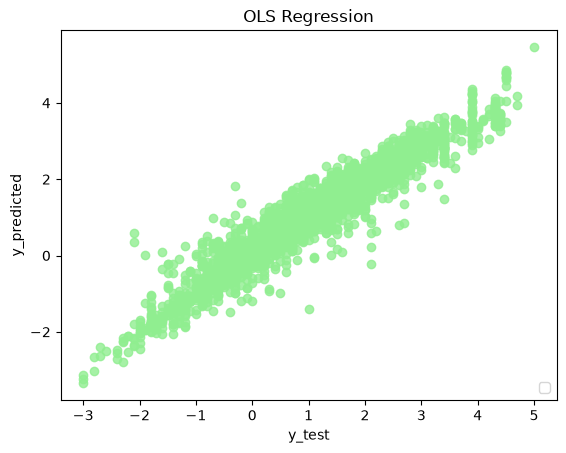

In [185]:
# printing values
print('Slope:' ,regression_model.coef_)
print('Intercept:', regression_model.intercept_)
print('Mean squared error: ', mse)
print('R2 score: ', r2)

# predicted values
plt.scatter(y_test, y_predicted, color='lightgreen', alpha = 0.8)
plt.xlabel('y_test')
plt.ylabel('y_predicted')
plt.title('OLS Regression')
plt.legend(loc=4)
plt.savefig('LR Predictor.png', dpi=300)
plt.show()

# RIDGE AND LASSO REGRESSION 

Slope: [-1.47354536e-02  1.08004866e+00 -5.24225992e+00  4.21346139e+00
 -1.84400575e-02 -1.61984225e-02 -1.07823323e-03 -3.80609042e-02
  1.41522181e-01  1.96117096e-01 -4.34716141e-01  3.27504984e-01
  9.44933714e-02  7.64260883e-01  1.33793167e-01 -3.21634032e-01
  1.22635194e-01  1.21120930e-01  1.78595491e-02  1.72637666e-02
  1.84790216e-02  9.65886637e-02  1.20504488e-01 -8.15854144e-01
  9.96690822e-03  4.87636101e-01  4.85387944e-02 -1.03765443e-02
 -6.61813081e-02 -2.17569052e-01 -1.67660581e-01  1.08182371e-01
  3.77746221e-02 -3.69744359e-01 -6.81954853e-01  1.25589338e-01
  1.52680287e-02  2.28637257e-02 -1.85616395e-03  5.08440270e-01
  1.19848348e-02 -1.68909503e-01 -6.44343888e-02  1.17640064e-02
 -1.12401970e-01 -1.99287944e-01]
Intercept: 0.9777405546250436
mean squared error:  0.13236724759076862
R2 score:  0.9201531410150403


Text(0.5, 1.0, 'Ridge Regression with alpha = 0.1')

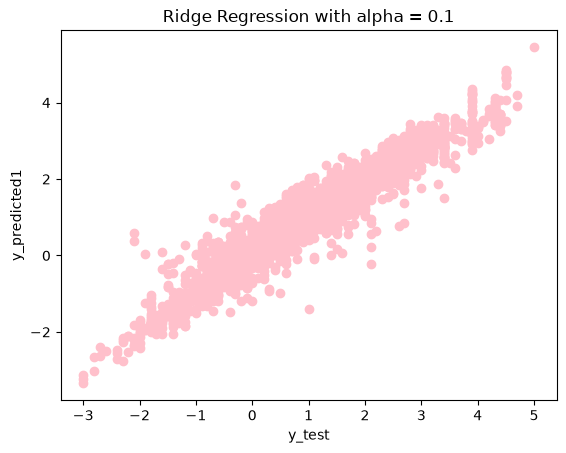

In [186]:
# Model initialization
ridge_model = Ridge(alpha=0.1)    
# Fit the data(train the model)
ridge_model.fit(X_train, y_train)
# Predict
y_predicted1 = ridge_model.predict(X_test)

# model evaluation
mse = mean_squared_error(y_test, y_predicted1)
r2 = r2_score(y_test, y_predicted1)

# printing values
print('Slope:' ,ridge_model.coef_)
print('Intercept:', ridge_model.intercept_)
print('mean squared error: ', mse)
print('R2 score: ', r2)

# plotting values
plt.scatter(y_test, y_predicted1, color='pink')
plt.xlabel('y_test')
plt.ylabel('y_predicted1')
plt.title('Ridge Regression with alpha = 0.1')



Slope: [ 0.          0.          0.          0.          0.          0.
 -0.          0.          0.         -0.         -0.          0.187663
  0.10077544  0.          0.07977455  0.          0.07960354  0.23531639
  0.          0.          0.00398782  0.01355297  0.          0.
  0.          0.16566444  0.00358191 -0.         -0.         -0.
 -0.         -0.         -0.         -0.20589181 -0.40284585 -0.
 -0.         -0.20812406 -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.        ]
Intercept: 0.9777405546249778
Root mean squared error:  0.2500572126544952
R2 score:  0.8491599443185217


Text(0.5, 1.0, 'Lasso Regression with alpha = 0.1')

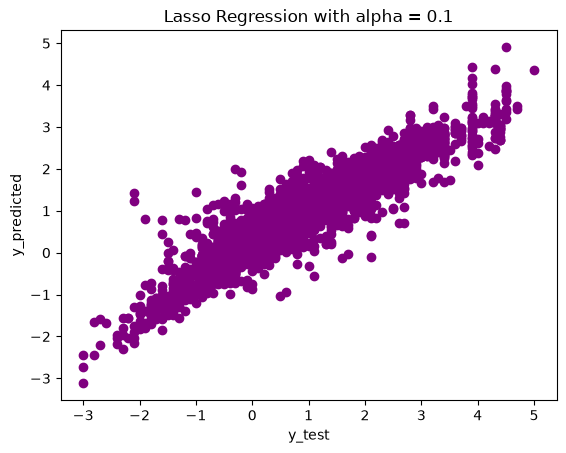

In [187]:
# Model initialization
lasso_model = Lasso(alpha=0.1)    
# Fit the data(train the model)
lasso_model.fit(X_train, y_train)
# Predict
y_predicted2 = lasso_model.predict(X_test)

# model evaluation
mse = mean_squared_error(y_test, y_predicted2)
r2 = r2_score(y_test, y_predicted2)

# printing values
print('Slope:' ,lasso_model.coef_)
print('Intercept:', lasso_model.intercept_)
print('Root mean squared error: ', mse)
print('R2 score: ', r2)

# predicted values
plt.scatter(y_test,y_predicted2,color='purple')
plt.xlabel('y_test')
plt.ylabel('y_predicted')
plt.title('Lasso Regression with alpha = 0.1')


# HYPERPARAMETERS  TUNING FOR RIDGE AND LASSO REGRESSION 

In [188]:
ridge_cv = RidgeCV(alphas=np.linspace(0.01, 1.0, 10))
ridge_cv.fit(X_train,y_train)
print(ridge_cv.alpha_)     
print(ridge_cv.score(X_test,y_test)) 

0.01
0.9202435718765942


In [189]:
lasso_cv = LassoCV(alphas=np.linspace(0.01, 1.0, 10))
lasso_cv.fit(X_train,y_train.ravel())   

print(lasso_cv.alpha_)   
print(lasso_cv.score(X_test,y_test))

0.01
0.9081828573323947


# RERUN RIDGE AND LASSO REGRESSION USING THE BEST PARAMETERS 

Slope: [-1.41540156e-02  2.49452150e-01 -5.57878852e+00  5.36861520e+00
 -2.07426087e-02 -1.92374603e-02 -2.82639271e-04 -3.62156949e-02
  1.63835955e-01  2.01313461e-01 -4.44573497e-01  3.43797692e-01
  9.48077867e-02  7.86212330e-01  1.34789848e-01 -3.22440935e-01
  1.21663299e-01  1.05724236e-01  1.81968762e-02  1.87951602e-02
  1.74646120e-02  9.86660881e-02  1.21465849e-01 -8.74562826e-01
  1.06878238e-02  4.92044554e-01  4.97841176e-02 -1.28109043e-02
 -6.57846370e-02 -2.32714490e-01 -1.71652327e-01  1.06590274e-01
  3.51837186e-02 -3.74218363e-01 -6.84020346e-01  1.28383572e-01
  1.61753139e-02  2.20948043e-02 -9.06101220e-04  5.10974239e-01
  1.51543661e-02 -1.68138565e-01 -6.47565860e-02  1.30516956e-02
 -1.12312884e-01 -2.00716319e-01]
Intercept: 0.9777405546250387
Root mean squared error:  0.13221733456479146
R2 score:  0.9202435718766249


Text(0.5, 1.0, 'Ridge Regression with alpha = 0.01')

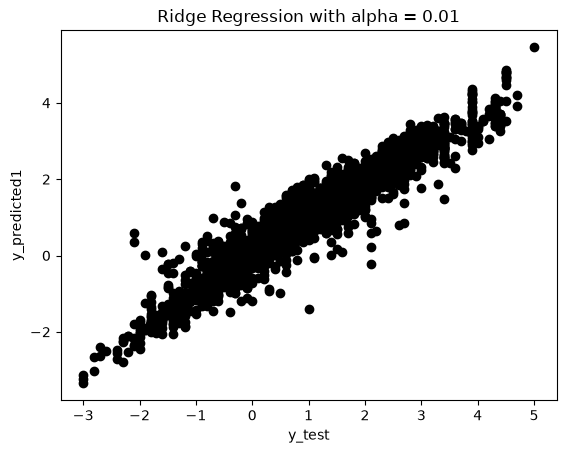

In [190]:
###Ridge regression###
# Model initialization
ridge_model = Ridge(alpha=0.01)    
# Fit the data(train the model)
ridge_model.fit(X_train, y_train)
# Predict
y_predicted1 = ridge_model.predict(X_test)

# model evaluation
mse = mean_squared_error(y_test, y_predicted1)
r2 = r2_score(y_test, y_predicted1)

# printing values
print('Slope:' ,ridge_model.coef_)
print('Intercept:', ridge_model.intercept_)
print('Root mean squared error: ', mse)
print('R2 score: ', r2)

# plotting values
plt.scatter(y_test, y_predicted1, color='black')
plt.xlabel('y_test')
plt.ylabel('y_predicted1')
plt.title('Ridge Regression with alpha = 0.01')



Slope: [-0.          0.          0.          0.          0.          0.01168071
 -0.025687   -0.02101539 -0.          0.00121812 -0.08885554  0.21559989
  0.09604209  0.          0.         -0.          0.10926638  0.33411507
  0.01823736  0.0147892   0.07530308  0.0690135   0.08209468 -0.
  0.          0.42291287  0.03370971  0.         -0.05792503  0.
 -0.10873045 -0.         -0.         -0.22577483 -0.39861674  0.
 -0.02052244 -0.06465149 -0.03216864  0.325729   -0.07328558 -0.19090905
 -0.02966984 -0.         -0.         -0.10909648]
Intercept: 0.9777405546249786
Root mean squared error:  0.15221115283757297
R2 score:  0.9081828573323947


Text(0.5, 1.0, 'Lasso Regression with alpha = 0.01')

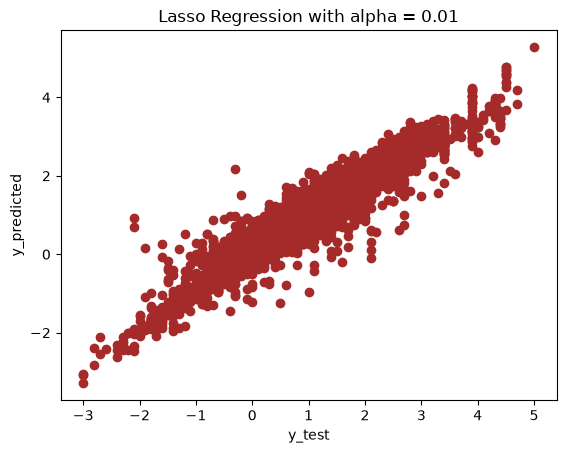

In [191]:
###Lasso Regression###
# Model initialization
lasso_model = Lasso(alpha=0.01)    
# Fit the data(train the model)
lasso_model.fit(X_train, y_train)
# Predict
y_predicted2 = lasso_model.predict(X_test)

# model evaluation
mse = mean_squared_error(y_test, y_predicted2)
r2 = r2_score(y_test, y_predicted2)

# printing values
print('Slope:' ,lasso_model.coef_)
print('Intercept:', lasso_model.intercept_)
print('Root mean squared error: ', mse)
print('R2 score: ', r2)

# predicted values
plt.scatter(y_test,y_predicted2,color='brown')
plt.xlabel('y_test')
plt.ylabel('y_predicted')
plt.title('Lasso Regression with alpha = 0.01')


# PIPELINE FOR OTHER REGRESSION ALGORITHMS 

In [192]:
## Construct Pipeline ##

print("R2 scores")

# KNN Regression Pipeline
KNN_pipe = Pipeline([('scl', StandardScaler()),
                    ('rg', KNeighborsRegressor(n_neighbors=2))])

# Random Forest Regression Pipeline
rf_pipe = Pipeline([('scl', StandardScaler()),
                    ('rg', RandomForestRegressor(n_estimators=100))])


# Support Vector Regression (SVR) pipeline
svr_pipe = Pipeline([('scl', StandardScaler()),
                    ('rg', SVR(C=1.0, epsilon=0.2))])

# Decision Tree Regression pipeline
dt_pipe = Pipeline([('scl', StandardScaler()),
                   ('rg', DecisionTreeRegressor(random_state = 0))])

#Gradient Boosting Regression pipeline
gb_pipe = Pipeline([('scl', StandardScaler()),
                    ('rg', GradientBoostingRegressor(random_state = 0))])

# List of pipelines for ease of iteration
pipelines = [KNN_pipe, rf_pipe, svr_pipe, dt_pipe, gb_pipe]

# Dictionary of pipelines and classifier types for ease of reference
pipe_dict = {0:'KNN Regression', 1:'Random Forest Regression', 2:'Support Vector Regression',
             3:'Decision Tree Regression', 4:'Gradient Boosting Regression'}

# Fit the pipelines
for pipe in pipelines:
    pipe.fit(X_train, y_train)
    
    
# Compare accuracies
for idx, val in enumerate(pipelines):
    print('%s pipeline test R2 score: %.3f' % (pipe_dict[idx], val.score(X_test, y_test)))
    
# Identify the most accurate model on test data
best_acc = 0.0
best_rg = 0
best_pipe = ''
for idx, val in enumerate(pipelines):
    if val.score(X_test, y_test) > best_acc:
        best_acc = val.score(X_test, y_test)
        best_pipe = val
        best_rg = idx
print('Best regression model: %s' % pipe_dict[best_rg])

# Save pipeline to file
joblib.dump(best_pipe, 'best_pipeline.pkl', compress=1)
print('Saved %s pipeline to file' % pipe_dict[best_rg])

print()
print("MSE scores")

KNN_y_pred = KNN_pipe.predict(X_test)
print("KNN Regression MSE score:",mean_squared_error(y_test, KNN_y_pred))

rf_y_pred = rf_pipe.predict(X_test)
print("Random Forest MSE score:", mean_squared_error(y_test, rf_y_pred))

svr_y_pred = svr_pipe.predict(X_test)
print("SVR MSE score:", mean_squared_error(y_test, svr_y_pred))

dt_y_pred = dt_pipe.predict(X_test)
print("Decision Tree MSE score:", mean_squared_error(y_test, dt_y_pred))

gb_y_pred = gb_pipe.predict(X_test)
print("Gradient Boosting Regression MSE score:", mean_squared_error(y_test, gb_y_pred))

R2 scores
KNN Regression pipeline test R2 score: 0.928
Random Forest Regression pipeline test R2 score: 0.960
Support Vector Regression pipeline test R2 score: 0.960
Decision Tree Regression pipeline test R2 score: 0.919
Gradient Boosting Regression pipeline test R2 score: 0.937
Best regression model: Random Forest Regression
Saved Random Forest Regression pipeline to file

MSE scores
KNN Regression MSE score: 0.12017513257047166
Random Forest MSE score: 0.06559033268210995
SVR MSE score: 0.06641555358349281
Decision Tree MSE score: 0.1342506279653921
Gradient Boosting Regression MSE score: 0.10404022923154624


Text(0.5, 1.0, 'KNN Regression with alpha = 0.01')

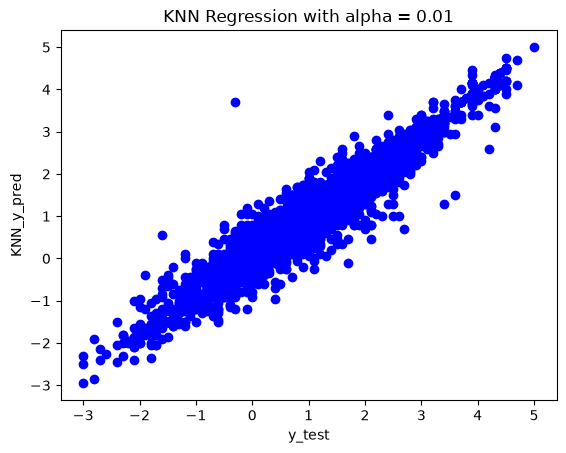

In [193]:
# plotting values
plt.scatter(y_test, KNN_y_pred, color='blue')
plt.xlabel('y_test')
plt.ylabel('KNN_y_pred')
plt.title('KNN Regression with alpha = 0.01')


Text(0.5, 1.0, 'Random Forest with alpha = 0.01')

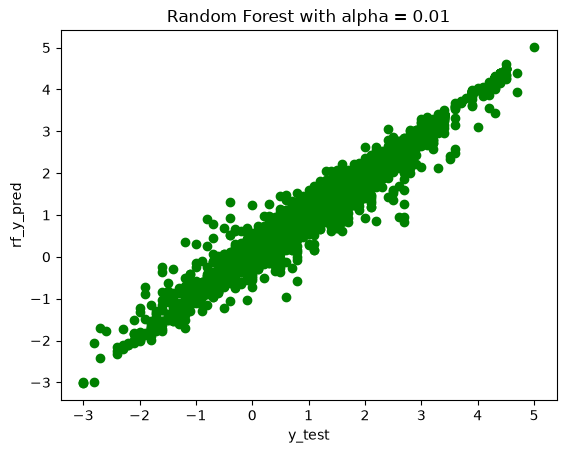

In [194]:
plt.scatter(y_test, rf_y_pred, color='green')
plt.xlabel('y_test')
plt.ylabel('rf_y_pred')
plt.title('Random Forest with alpha = 0.01')


Text(0.5, 1.0, 'Support Vector Regression with alpha = 0.01')

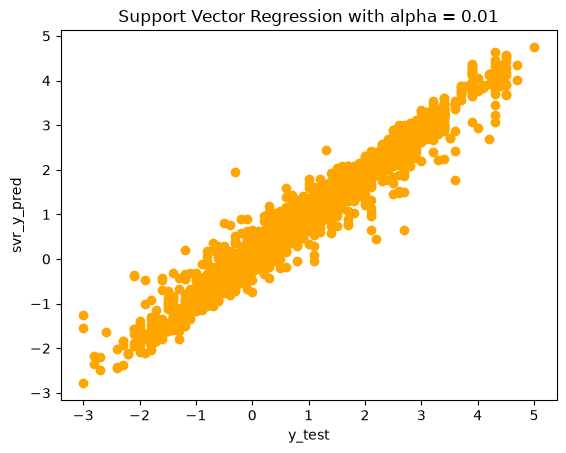

In [195]:
plt.scatter(y_test, svr_y_pred, color='orange')
plt.xlabel('y_test')
plt.ylabel('svr_y_pred')
plt.title('Support Vector Regression with alpha = 0.01')


Text(0.5, 1.0, 'Decision Tree Regression with alpha = 0.01')

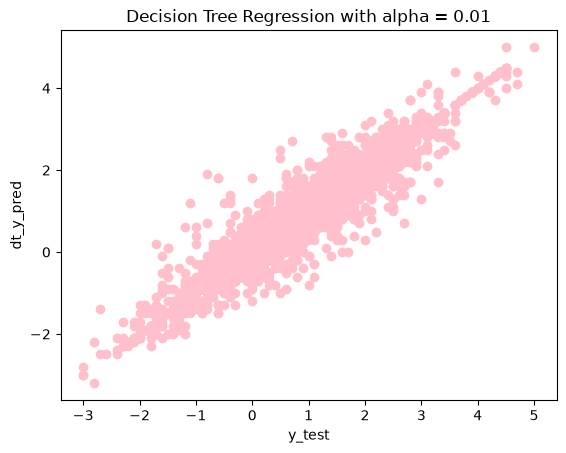

In [196]:
plt.scatter(y_test, dt_y_pred, color='pink')
plt.xlabel('y_test')
plt.ylabel('dt_y_pred')
plt.title('Decision Tree Regression with alpha = 0.01')


Text(0.5, 1.0, 'Gradient Boosting Regression with alpha = 0.01')

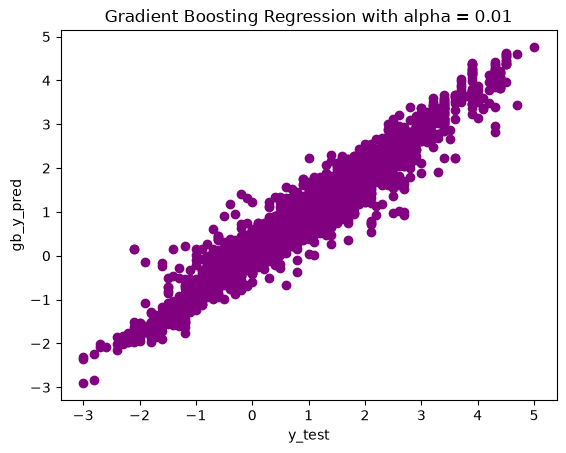

In [197]:
plt.scatter(y_test, gb_y_pred, color='purple')
plt.xlabel('y_test')
plt.ylabel('gb_y_pred')
plt.title('Gradient Boosting Regression with alpha = 0.01')


# HYPERPARAMETER TUNING USING GRID SEARCH

In [198]:
print('Using Grid Search')
print('Best hyperparameters for each regression and its R2 score')
print()

##Hyperparameter tuning for KNN Regression##
print('KNN Regression')

grid_params_knn = {'rg__n_neighbors':[1,2,3,4,5,6,7,8,9],
                   'rg__leaf_size' : [2,5,10]}  

gs_knn = GridSearchCV(estimator=KNN_pipe,
            param_grid=grid_params_knn,
            scoring= "r2"
            ,cv=5, verbose=2, n_jobs=-1)

# Fit using grid search
gs_knn.fit(X_train, y_train)


##Hyperparameter tuning for Random Forest Regression##
print('Random Forest Regression')

grid_params_rf = {'rg__n_estimators': [10, 50, 100, 150],  
                  'rg__max_features': [1.0, 'sqrt'], 
                  'rg__max_depth': [80, 90, 100, 110]} 

gs_rf = GridSearchCV(estimator=rf_pipe,
            param_grid=grid_params_rf,
            scoring='r2',
            cv=5, verbose=2, n_jobs=-1)

# Fit using grid search
gs_rf.fit(X_train, y_train)


##Hyperparameter tuning for Support Vector Regression##
print('Support Vector Regression')

grid_params_svr = {'rg__kernel': ['linear', 'poly', 'rbf','sigmoid'],
                   'rg__epsilon': [0.1, 0.2, 0.3],
                   'rg__C': [1.0, 2.0, 3.0]}  

gs_svr = GridSearchCV(estimator=svr_pipe,
            param_grid=grid_params_svr,
            scoring='r2',
            cv=5, verbose=2, n_jobs=-1)

# Fit using grid search
gs_svr.fit(X_train, y_train)




##Hyperparameter tuning for Decision Tree Regression##
print('Decision Tree Regression')

grid_params_dt = {'rg__random_state': [0, 42, None],
                  'rg__max_depth': [80, 90, 100, 110],
                  'rg__max_features': ['sqrt', 'log2', None]}  

gs_dt = GridSearchCV(estimator=dt_pipe,
            param_grid=grid_params_dt,
            scoring= "r2"
            ,cv=5, verbose=2, n_jobs=-1)

# Fit using grid search
gs_dt.fit(X_train, y_train)


##Hyperparameter tuning for Gradient Boosting Regression##
print('Gradient Boosting Regression')

grid_params_gb = {'rg__random_state': [0, 42, None],
                  'rg__max_depth': [1, 2, 3, 5],
                  'rg__max_features': ['sqrt', 'log2', None]}  

gs_gb = GridSearchCV(estimator=gb_pipe,
            param_grid=grid_params_gb,
            scoring='r2',
            cv=5, verbose=2, n_jobs=-1)

# Fit using grid search
gs_gb.fit(X_train, y_train)
# Best accuracy
print('KNN Best R2 score: %.3f' % gs_knn.best_score_)

# Best params
print('\nKNN Best params:\n', gs_knn.best_params_)
print()

# Best accuracy
print('RF Best R2 score: %.3f' % gs_rf.best_score_)

# Best params
print('\nRF Best params:\n', gs_rf.best_params_)
print()

# Best accuracy
print('SVR Best R2 score: %.3f' % gs_svr.best_score_)

# Best params
print('\nSVR Best params:\n', gs_svr.best_params_)
print()

# Best accuracy
print('DT Best R2 score: %.3f' % gs_dt.best_score_)

# Best params
print('\nDT Best params:\n', gs_dt.best_params_)
print()


# Best accuracy
print('GB Best R2 score: %.3f' % gs_gb.best_score_)

# Best params
print('\nGB Best params:\n', gs_gb.best_params_)

Using Grid Search
Best hyperparameters for each regression and its R2 score

KNN Regression
Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END .................rg__leaf_size=2, rg__n_neighbors=1; total time=   0.1s
[CV] END .................rg__leaf_size=2, rg__n_neighbors=1; total time=   0.1s
[CV] END .................rg__leaf_size=2, rg__n_neighbors=1; total time=   0.1s
[CV] END .................rg__leaf_size=2, rg__n_neighbors=1; total time=   0.1s
[CV] END .................rg__leaf_size=2, rg__n_neighbors=2; total time=   0.1s
[CV] END .................rg__leaf_size=2, rg__n_neighbors=1; total time=   0.1s
[CV] END .................rg__leaf_size=2, rg__n_neighbors=2; total time=   0.1s
[CV] END .................rg__leaf_size=2, rg__n_neighbors=2; total time=   0.1s
[CV] END .................rg__leaf_size=2, rg__n_neighbors=2; total time=   0.1s
[CV] END .................rg__leaf_size=2, rg__n_neighbors=2; total time=   0.1s
[CV] END .................rg__leaf_s

/Users/xianliangchu/Desktop/CM4044 Mini Project II Group 8/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END rg__max_depth=80, rg__max_features=sqrt, rg__n_estimators=10; total time=   0.2s
[CV] END rg__max_depth=80, rg__max_features=1.0, rg__n_estimators=100; total time=   9.6s
[CV] END rg__max_depth=80, rg__max_features=1.0, rg__n_estimators=100; total time=   9.6s
[CV] END rg__max_depth=80, rg__max_features=sqrt, rg__n_estimators=50; total time=   0.9s
[CV] END rg__max_depth=80, rg__max_features=sqrt, rg__n_estimators=50; total time=   0.8s
[CV] END rg__max_depth=80, rg__max_features=sqrt, rg__n_estimators=50; total time=   0.8s
[CV] END rg__max_depth=80, rg__max_features=sqrt, rg__n_estimators=50; total time=   0.9s
[CV] END rg__max_depth=80, rg__max_features=sqrt, rg__n_estimators=50; total time=   0.8s
[CV] END rg__max_depth=80, rg__max_features=sqrt, rg__n_estimators=100; total time=   1.7s
[CV] END rg__max_depth=80, rg__max_features=sqrt, rg__n_estimators=100; total time=   1.6s
[CV] END rg__max_depth=80, rg__max_features=sqrt, rg__n_estimators=100; total time=   1.6s
[CV] EN

# RERUN PIPELINE WITH BEST PARAMETERS

In [199]:
'''
KNN Best params:
 {'rg__leaf_size': 2, 'rg__n_neighbors': 4}

RF Best R2 score: 0.954

RF Best params:
 {'rg__max_depth': 100, 'rg__max_features': 'sqrt', 'rg__n_estimators': 150}

SVR Best R2 score: 0.967

SVR Best params:
 {'rg__C': 3.0, 'rg__epsilon': 0.1, 'rg__kernel': 'rbf'}

DT Best R2 score: 0.896

DT Best params:
 {'rg__max_depth': 90, 'rg__max_features': None, 'rg__random_state': None}

GB Best R2 score: 0.955

GB Best params:
 {'rg__max_depth': 5, 'rg__max_features': None, 'rg__random_state': 42}

'''

print('After hyperparameter tuning')
print()

# KNN Regression Pipeline
KNN_pipe = Pipeline([('scl', StandardScaler()),
                    ('rg', KNeighborsRegressor(n_neighbors=4, leaf_size=2))])

# Random Forest Regression Pipeline
rf_pipe = Pipeline([('scl', StandardScaler()),
                    ('rg', RandomForestRegressor(max_features='sqrt', n_estimators=150, max_depth=100))])


#Support Vector Regression (SVR) pipeline
svr_pipe = Pipeline([('scl', StandardScaler()),
                    ('rg', SVR(kernel='rbf', epsilon=0.1, C=3.0))])

#Decision Tree Regression pipeline
dt_pipe = Pipeline([('scl', StandardScaler()),
                   ('rg', DecisionTreeRegressor(random_state = None, max_depth=90, max_features=None))])

#Gradient Boosting Regression pipeline
gb_pipe = Pipeline([('scl', StandardScaler()),
                    ('rg', GradientBoostingRegressor(random_state =42, max_depth=5, max_features=None))])

# List of pipelines for ease of iteration
pipelines = [KNN_pipe, rf_pipe, svr_pipe, dt_pipe, gb_pipe]

# Dictionary of pipelines and classifier types for ease of reference
pipe_dict = {0:'KNN Regression', 1:'Random Forest Regression', 2:'Support Vector Regression',
             3:'Decision Tree Regression', 4:'Gradient Boosting Regression'}

# Fit the pipelines
for pipe in pipelines:
    pipe.fit(X_train, y_train)
    
    
# Compare accuracies
for idx, val in enumerate(pipelines):
    print('%s pipeline test R2 score: %.3f' % (pipe_dict[idx], val.score(X_test, y_test)))
    
# Identify the most accurate model on test data
best_acc = 0.0
best_rg = 0
best_pipe = ''
for idx, val in enumerate(pipelines):
    if val.score(X_test, y_test) > best_acc:
        best_acc = val.score(X_test, y_test)
        best_pipe = val
        best_rg = idx
print('Best regression model: %s' % pipe_dict[best_rg])

# Save pipeline to file
joblib.dump(best_pipe, 'best_pipeline.pkl', compress=1)
print('Saved %s pipeline to file' % pipe_dict[best_rg])

print()
print("MSE scores:")

KNN_y_pred = KNN_pipe.predict(X_test)
print("KNN Regression MSE score:",mean_squared_error(y_test, KNN_y_pred))

rf_y_pred = rf_pipe.predict(X_test)
print("Random Forest MSE score:", mean_squared_error(y_test, rf_y_pred))

svr_y_pred = svr_pipe.predict(X_test)
print("SVR MSE score:", mean_squared_error(y_test, svr_y_pred))

dt_y_pred = dt_pipe.predict(X_test)
print("Decision Tree MSE score:", mean_squared_error(y_test, dt_y_pred))

gb_y_pred = gb_pipe.predict(X_test)
print("Gradient Boosting Regression MSE score:", mean_squared_error(y_test, gb_y_pred))

After hyperparameter tuning

KNN Regression pipeline test R2 score: 0.932
Random Forest Regression pipeline test R2 score: 0.958
Support Vector Regression pipeline test R2 score: 0.973
Decision Tree Regression pipeline test R2 score: 0.919
Gradient Boosting Regression pipeline test R2 score: 0.959
Best regression model: Support Vector Regression
Saved Support Vector Regression pipeline to file

MSE scores:
KNN Regression MSE score: 0.11343811052190902
Random Forest MSE score: 0.0698935147417605
SVR MSE score: 0.04518182022093807
Decision Tree MSE score: 0.1345157689087357
Gradient Boosting Regression MSE score: 0.06828885720109742
